# Impact of Simulation Repetitions (R) on Solution Quality

This notebook investigates how the number of game simulations per fitness evaluation (R) affects:

1. **Solution quality**: Does higher R lead to better Pareto fronts?
2. **Fitness noise**: How much variance exists in objective estimates?
3. **Convergence behavior**: Does noisy fitness slow down optimization?
4. **Computational trade-off**: Is the extra cost of higher R worth it?

## Background

Each fitness evaluation runs R game simulations and averages the results. Since each game has stochastic elements (card shuffling, starting player), the fitness estimate is noisy. Higher R reduces this noise but increases computation time linearly.

**Key question**: What is the optimal R that balances accuracy and efficiency?

In [1]:
import random
import time
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import rankdata

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.termination import get_termination

from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

## Top Trumps Implementation

In [2]:
class TopTrumpsSimulation:
    """TopTrumpsSimulation implements the basic TopTrumps game engine and agent-based simulation."""

    def __init__(self, num_cards=52, num_categories=6):
        self.K = num_cards
        self.L = num_categories
        self.set_random_deck()

    def _normalize_deck(self, deck):
        min_values = [0] * self.L
        max_values = [0] * self.L

        for cat in range(self.L):
            all_values = [card[cat] for card in deck]
            min_values[cat] = min(all_values)
            max_values[cat] = max(all_values)

        normalized_deck = []
        for card in deck:
            normalized_card = [0] * self.L
            for cat in range(self.L):
                normalized_card[cat] = (card[cat] - min_values[cat]) / (max_values[cat] - min_values[cat])
            normalized_deck.append(normalized_card)

        return normalized_deck

    def set_deck(self, deck_list):
        assert len(deck_list) == self.K * self.L
        deck = np.array_split(deck_list, self.K)
        self.deck = deck
        self._normalized_deck = self._normalize_deck(deck)

    def set_random_deck(self, value_range=(1, 10)):
        deck_list = np.random.uniform(value_range[0], value_range[1], self.K * self.L)
        self.set_deck(deck_list)

    def get_p0_choice(self, card):
        return card.index(max(card))

    def get_p4_choice(self, card, remaining_cards):
        best_prob = -1
        best_cat = 0
        for cat_idx in range(self.L):
            my_val = card[cat_idx]
            wins = sum(1 for opp_card in remaining_cards if my_val > opp_card[cat_idx])
            prob = wins / len(remaining_cards)
            if prob > best_prob:
                best_prob = prob
                best_cat = cat_idx
        return best_cat

    def simulate_game(self):
        temp_deck = list(self._normalized_deck)
        random.shuffle(temp_deck)

        p4_hand = temp_deck[:self.K//2]
        p0_hand = temp_deck[self.K//2:]
        all_unplayed = list(temp_deck)

        p4_tricks = 0
        current_turn = random.choice(['p4', 'p0'])
        trick_changes = 0

        for i in range(self.K // 2):
            card_p4 = p4_hand[i]
            card_p0 = p0_hand[i]

            if current_turn == 'p4':
                category = self.get_p4_choice(card_p4, all_unplayed)
            else:
                category = self.get_p0_choice(card_p0)

            val_p4 = card_p4[category]
            val_p0 = card_p0[category]

            all_unplayed.remove(card_p0)
            all_unplayed.remove(card_p4)

            if val_p4 > val_p0:
                p4_tricks += 1
                if current_turn == 'p0':
                    current_turn = 'p4'
                    trick_changes += 1
            elif val_p0 > val_p4:
                if current_turn == 'p4':
                    current_turn = 'p0'
                    trick_changes += 1

        return {
            "p4_tricks": p4_tricks,
            "trick_changes": trick_changes,
            "p4_won": p4_tricks > (self.K / 4)
        }

In [3]:
class TopTrumpsBalancing(ElementwiseProblem):
    """TopTrumpsBalancing with configurable simulation count."""

    def __init__(self, sim_instance, n_simulations=100):
        self.sim = sim_instance
        self.n_simulations = n_simulations
        n_var = self.sim.K * self.sim.L
        
        super().__init__(n_var=n_var,
                         n_obj=2,
                         n_constr=0,
                         xl=1.0,
                         xu=10.0)

    def _evaluate(self, x, out, *args, **kwargs):
        self.sim.set_deck(x)
        
        win_rates = []
        trick_changes_list = []
        
        for _ in range(self.n_simulations):
            res = self.sim.simulate_game()
            win_rates.append(1 if res['p4_won'] else 0)
            trick_changes_list.append(res['trick_changes'])
        
        out["F"] = [
            -np.mean(win_rates), 
            -np.mean(trick_changes_list)
        ]

## Part 1: Fitness Noise Analysis

First, let's understand how noisy the fitness estimates are for different R values. We'll evaluate the same deck configuration multiple times and measure the variance.

In [4]:
# Create a fixed test deck
np.random.seed(42)
sim = TopTrumpsSimulation(num_cards=22, num_categories=4)
test_deck = np.random.uniform(1.0, 10.0, sim.K * sim.L)

# R values to test
R_values = [50, 100, 250, 500, 1000, 2000]
n_repeats = 30  # Number of times to evaluate the same deck

noise_results = {}

for R in R_values:
    print(f"Testing R={R}...")
    problem = TopTrumpsBalancing(sim, n_simulations=R)
    
    fairness_samples = []
    excitement_samples = []
    
    for _ in range(n_repeats):
        out = {}
        problem._evaluate(test_deck, out)
        fairness_samples.append(-out["F"][0])  # Negate back
        excitement_samples.append(-out["F"][1])
    
    noise_results[R] = {
        'fairness_mean': np.mean(fairness_samples),
        'fairness_std': np.std(fairness_samples),
        'excitement_mean': np.mean(excitement_samples),
        'excitement_std': np.std(excitement_samples),
        'fairness_samples': fairness_samples,
        'excitement_samples': excitement_samples
    }

print("\nNoise Analysis Results:")
print("="*70)
print(f"{'R':>6} | {'Fairness Mean':>14} | {'Fairness Std':>12} | {'Excitement Mean':>15} | {'Excitement Std':>14}")
print("="*70)
for R, data in noise_results.items():
    print(f"{R:>6} | {data['fairness_mean']:>14.4f} | {data['fairness_std']:>12.4f} | {data['excitement_mean']:>15.4f} | {data['excitement_std']:>14.4f}")

Testing R=50...
Testing R=100...
Testing R=250...
Testing R=500...
Testing R=1000...
Testing R=2000...

Noise Analysis Results:
     R |  Fairness Mean | Fairness Std | Excitement Mean | Excitement Std
    50 |         0.5693 |       0.0806 |          1.9467 |         0.1987
   100 |         0.5663 |       0.0395 |          1.9803 |         0.1218
   250 |         0.5644 |       0.0301 |          1.9465 |         0.0827
   500 |         0.5647 |       0.0279 |          1.9666 |         0.0506
  1000 |         0.5622 |       0.0152 |          1.9596 |         0.0404
  2000 |         0.5624 |       0.0122 |          1.9471 |         0.0272


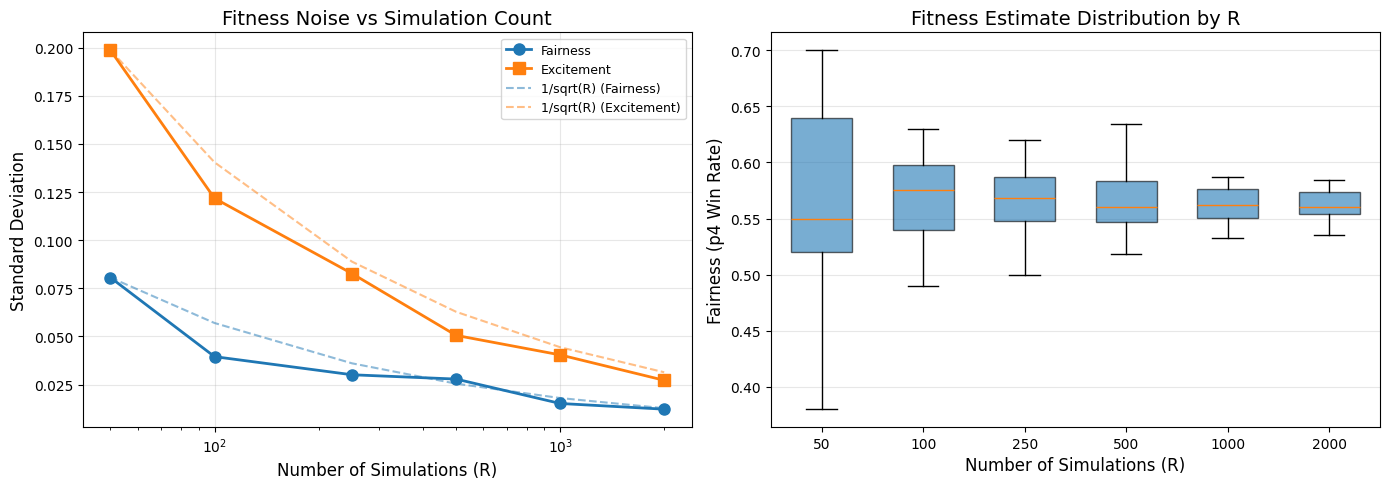

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

R_vals = list(noise_results.keys())
fairness_stds = [noise_results[R]['fairness_std'] for R in R_vals]
excitement_stds = [noise_results[R]['excitement_std'] for R in R_vals]

# Plot standard deviation vs R
axes[0].plot(R_vals, fairness_stds, 'o-', color='tab:blue', linewidth=2, markersize=8, label='Fairness')
axes[0].plot(R_vals, excitement_stds, 's-', color='tab:orange', linewidth=2, markersize=8, label='Excitement')
axes[0].set_xlabel('Number of Simulations (R)', fontsize=12)
axes[0].set_ylabel('Standard Deviation', fontsize=12)
axes[0].set_title('Fitness Noise vs Simulation Count', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Theoretical 1/sqrt(R) decay
R_theory = np.array(R_vals)
scale_f = fairness_stds[0] * np.sqrt(R_vals[0])
scale_e = excitement_stds[0] * np.sqrt(R_vals[0])
axes[0].plot(R_theory, scale_f / np.sqrt(R_theory), '--', color='tab:blue', alpha=0.5, label='1/sqrt(R) (Fairness)')
axes[0].plot(R_theory, scale_e / np.sqrt(R_theory), '--', color='tab:orange', alpha=0.5, label='1/sqrt(R) (Excitement)')
axes[0].legend(fontsize=9)

# Box plot of samples for each R
positions = np.arange(len(R_vals))
fairness_data = [noise_results[R]['fairness_samples'] for R in R_vals]
bp = axes[1].boxplot(fairness_data, positions=positions, widths=0.6, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('tab:blue')
    patch.set_alpha(0.6)
axes[1].set_xticks(positions)
axes[1].set_xticklabels([str(R) for R in R_vals])
axes[1].set_xlabel('Number of Simulations (R)', fontsize=12)
axes[1].set_ylabel('Fairness (p4 Win Rate)', fontsize=12)
axes[1].set_title('Fitness Estimate Distribution by R', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Part 2: Optimization with Different R Values

Now let's run the full optimization with different R values and compare the resulting Pareto fronts.

In [7]:
def run_optimization_with_R(R, n_gen):
    """Run optimization with specified R value."""
    sim = TopTrumpsSimulation(num_cards=22, num_categories=4)
    problem = TopTrumpsBalancing(sim, n_simulations=R)
    
    algorithm = NSGA2(
        pop_size=100,
        n_offsprings=50,
        sampling=LHS(),
        crossover=SBX(prob=0.9, eta=10),
        mutation=PM(eta=15, prob=1.0/problem.n_var),
        eliminate_duplicates=True
    )
    
    termination = get_termination("n_gen", n_gen)
    
    start_time = time.time()
    result = minimize(
        problem,
        algorithm,
        termination,
        seed=42,
        save_history=True,
        verbose=False
    )
    elapsed = time.time() - start_time
    
    return result, elapsed, problem

In [8]:
# R values to compare (including R=5000 for complete analysis)
# R=5000 serves as both optimization setting AND validation baseline
R_test_values = [100, 250, 500, 1000, 2000, 5000]
N_GEN = 100

optimization_results = {}

for R in R_test_values:
    print(f"\nRunning optimization with R={R}...")
    result, elapsed, problem = run_optimization_with_R(R, n_gen=N_GEN)
    optimization_results[R] = {
        'result': result,
        'runtime': elapsed,
        'problem': problem
    }
    print(f"  Found {len(result.F)} solutions in {elapsed:.1f}s")

print("\nOptimization complete!")


Running optimization with R=100...
  Found 4 solutions in 11.8s

Running optimization with R=250...
  Found 10 solutions in 28.3s

Running optimization with R=500...
  Found 29 solutions in 56.6s

Running optimization with R=1000...
  Found 18 solutions in 112.6s

Running optimization with R=2000...
  Found 39 solutions in 222.3s

Running optimization with R=5000...
  Found 44 solutions in 556.9s

Optimization complete!


## Part 3: Re-evaluation with High-Fidelity Simulations

**Critical insight**: The Pareto fronts found during optimization have noisy fitness estimates. To fairly compare which R value produces truly better solutions, we re-evaluate ALL solutions using R=10000 simulations.

**Why re-evaluate?**
- During optimization with R=100, a solution might appear to have fairness=0.75
- But the TRUE fitness (with enough samples) might be 0.68
- By re-evaluating with R=10000, we get accurate "ground truth" fitness values
- This reveals which optimization R actually found better solutions vs. just got lucky with noise

**Note**: R=10000 is chosen to be higher than any optimization R (up to 5000) to ensure unbiased validation.

In [9]:
# High-fidelity evaluation (higher than any optimization R for unbiased comparison)
R_HIGH = 10000
print(f"Re-evaluating all solutions with R={R_HIGH} for accurate comparison...")
print("(This gives us the 'ground truth' fitness to compare which R found truly good solutions)\n")

sim_eval = TopTrumpsSimulation(num_cards=22, num_categories=4)
problem_eval = TopTrumpsBalancing(sim_eval, n_simulations=R_HIGH)

reevaluated_results = {}

for R, data in optimization_results.items():
    print(f"Re-evaluating R={R} solutions ({len(data['result'].X)} solutions)...")
    X = data['result'].X
    F_original = data['result'].F
    
    F_reevaluated = []
    for i, x in enumerate(X):
        out = {}
        problem_eval._evaluate(x, out)
        F_reevaluated.append(out["F"])
    
    F_reevaluated = np.array(F_reevaluated)
    
    reevaluated_results[R] = {
        'X': X,
        'F_original': F_original,
        'F_reevaluated': F_reevaluated
    }

print("\nRe-evaluation complete!")

Re-evaluating all solutions with R=10000 for accurate comparison...
(This gives us the 'ground truth' fitness to compare which R found truly good solutions)

Re-evaluating R=100 solutions (4 solutions)...
Re-evaluating R=250 solutions (10 solutions)...
Re-evaluating R=500 solutions (29 solutions)...
Re-evaluating R=1000 solutions (18 solutions)...
Re-evaluating R=2000 solutions (39 solutions)...
Re-evaluating R=5000 solutions (44 solutions)...

Re-evaluation complete!


## Part 4: Quality Metrics Comparison

Compare solution quality using:
- **Original metrics**: Based on noisy fitness from optimization
- **True metrics**: Based on high-fidelity re-evaluation

In [10]:
# Combine all re-evaluated fronts to create reference
all_F_reeval = np.vstack([data['F_reevaluated'] for data in reevaluated_results.values()])

# Find non-dominated solutions
nds = NonDominatedSorting()
fronts = nds.do(all_F_reeval)
reference_front = all_F_reeval[fronts[0]]

print(f"Reference front (combined non-dominated): {len(reference_front)} solutions")

# Reference point for hypervolume
ref_point = np.array([0.0, 0.0])

hv_indicator = HV(ref_point=ref_point)
igd_indicator = IGD(reference_front)

metrics_comparison = {}

for R in R_test_values:
    data = reevaluated_results[R]
    opt_data = optimization_results[R]
    
    # Original metrics (potentially misleading due to noise)
    hv_original = hv_indicator(data['F_original'])
    
    # True metrics (after re-evaluation)
    hv_true = hv_indicator(data['F_reevaluated'])
    igd_true = igd_indicator(data['F_reevaluated'])
    
    # Count how many solutions are actually non-dominated after re-evaluation
    fronts_reeval = nds.do(data['F_reevaluated'])
    n_nondom = len(fronts_reeval[0])
    
    metrics_comparison[R] = {
        'HV_original': hv_original,
        'HV_true': hv_true,
        'IGD_true': igd_true,
        'n_solutions': len(data['X']),
        'n_nondominated': n_nondom,
        'runtime': opt_data['runtime']
    }

print("\n" + "="*100)
print(f"{'R':>6} | {'HV (original)':>14} | {'HV (true)':>12} | {'IGD (true)':>12} | {'Solutions':>10} | {'Non-dom':>8} | {'Runtime':>10}")
print("="*100)
for R, m in metrics_comparison.items():
    print(f"{R:>6} | {m['HV_original']:>14.6f} | {m['HV_true']:>12.6f} | {m['IGD_true']:>12.6f} | {m['n_solutions']:>10} | {m['n_nondominated']:>8} | {m['runtime']:>9.1f}s")
print("="*100)

Reference front (combined non-dominated): 46 solutions

     R |  HV (original) |    HV (true) |   IGD (true) |  Solutions |  Non-dom |    Runtime
   100 |       3.993500 |     3.083820 |     0.401649 |          4 |        3 |      11.8s
   250 |       3.998032 |     3.540367 |     0.154467 |         10 |        7 |      28.3s
   500 |       4.118104 |     3.800259 |     0.053701 |         29 |       21 |      56.6s
  1000 |       3.788518 |     3.652158 |     0.101770 |         18 |       14 |     112.6s
  2000 |       3.880104 |     3.777692 |     0.025791 |         39 |       23 |     222.3s
  5000 |       3.579341 |     3.515666 |     0.106016 |         44 |       23 |     556.9s


## Part 5: Pareto Front Visualization

Compare the Pareto fronts found with different R values, showing both the original (noisy) positions and the true (re-evaluated) positions.

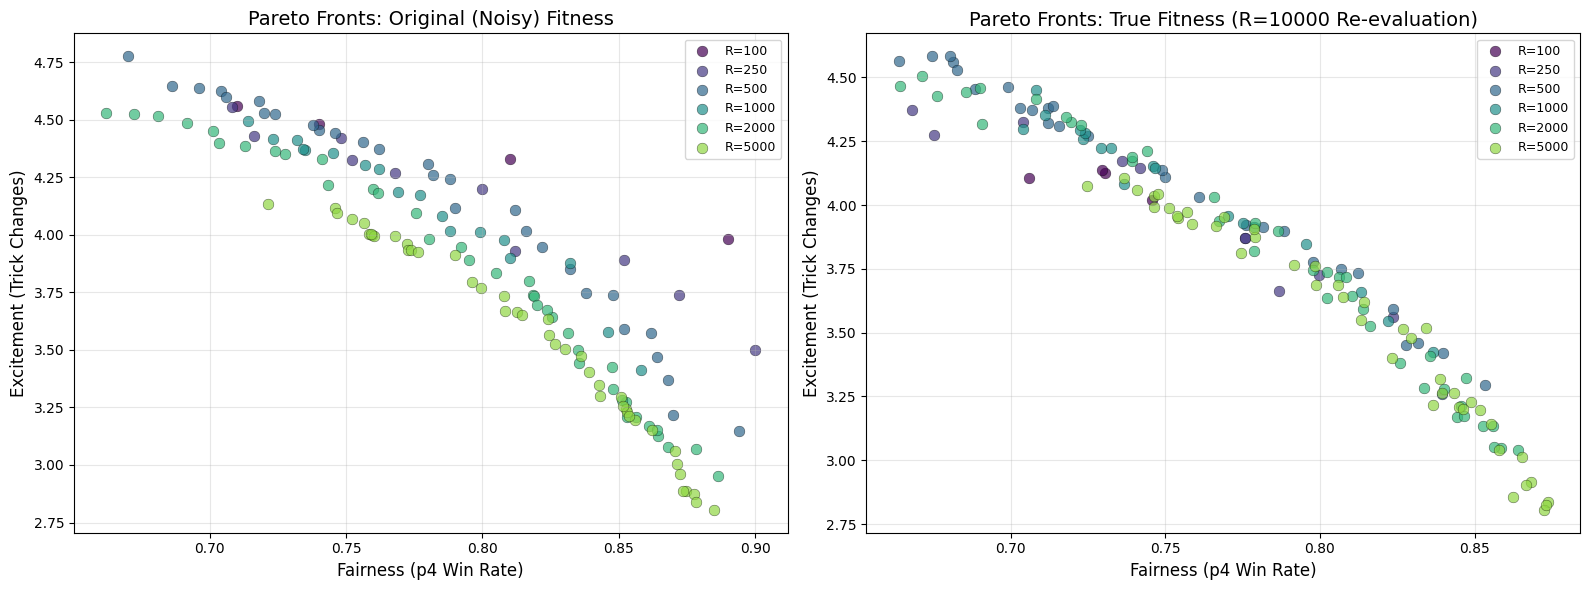

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.colormaps['viridis']
n_R = len(R_test_values)

# Left: Original (noisy) fitness values
ax = axes[0]
for i, R in enumerate(R_test_values):
    F = reevaluated_results[R]['F_original']
    ax.scatter(-F[:, 0], -F[:, 1], 
               c=[colors(i/n_R)], s=60, alpha=0.7, 
               edgecolors='black', linewidth=0.3,
               label=f'R={R}')
ax.set_xlabel('Fairness (p4 Win Rate)', fontsize=12)
ax.set_ylabel('Excitement (Trick Changes)', fontsize=12)
ax.set_title('Pareto Fronts: Original (Noisy) Fitness', fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: True (re-evaluated) fitness values
ax = axes[1]
for i, R in enumerate(R_test_values):
    F = reevaluated_results[R]['F_reevaluated']
    ax.scatter(-F[:, 0], -F[:, 1], 
               c=[colors(i/n_R)], s=60, alpha=0.7,
               edgecolors='black', linewidth=0.3,
               label=f'R={R}')
ax.set_xlabel('Fairness (p4 Win Rate)', fontsize=12)
ax.set_ylabel('Excitement (Trick Changes)', fontsize=12)
ax.set_title(f'Pareto Fronts: True Fitness (R={R_HIGH} Re-evaluation)', fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Analyze how much solutions "move" after re-evaluation
print("Solution Displacement Analysis")
print("(How much do fitness estimates change after high-fidelity re-evaluation?)\n")
print("="*70)
print(f"{'R':>6} | {'Mean Fairness Shift':>20} | {'Mean Excitement Shift':>22} | {'Total Displacement':>18}")
print("="*70)

for R in R_test_values:
    F_orig = reevaluated_results[R]['F_original']
    F_true = reevaluated_results[R]['F_reevaluated']
    
    # Calculate displacement in objective space
    displacement = np.abs(F_true - F_orig)
    mean_fair_shift = np.mean(displacement[:, 0])
    mean_excite_shift = np.mean(displacement[:, 1])
    
    # Euclidean displacement
    euclidean = np.sqrt(np.sum((F_true - F_orig)**2, axis=1))
    mean_displacement = np.mean(euclidean)
    
    print(f"{R:>6} | {mean_fair_shift:>20.4f} | {mean_excite_shift:>22.4f} | {mean_displacement:>18.4f}")

print("="*70)
print("\nNote: Lower displacement means the optimization had more accurate fitness estimates.")

Solution Displacement Analysis
(How much do fitness estimates change after high-fidelity re-evaluation?)

     R |  Mean Fairness Shift |  Mean Excitement Shift | Total Displacement
   100 |               0.0695 |                 0.2599 |             0.2936
   250 |               0.0441 |                 0.1390 |             0.1522
   500 |               0.0308 |                 0.0867 |             0.0997
  1000 |               0.0223 |                 0.0763 |             0.0857
  2000 |               0.0135 |                 0.0270 |             0.0323
  5000 |               0.0081 |                 0.0237 |             0.0263

Note: Lower displacement means the optimization had more accurate fitness estimates.


## Part 6: Convergence Analysis

Does higher R slow down convergence? Or does the reduced noise help the algorithm find better solutions faster?

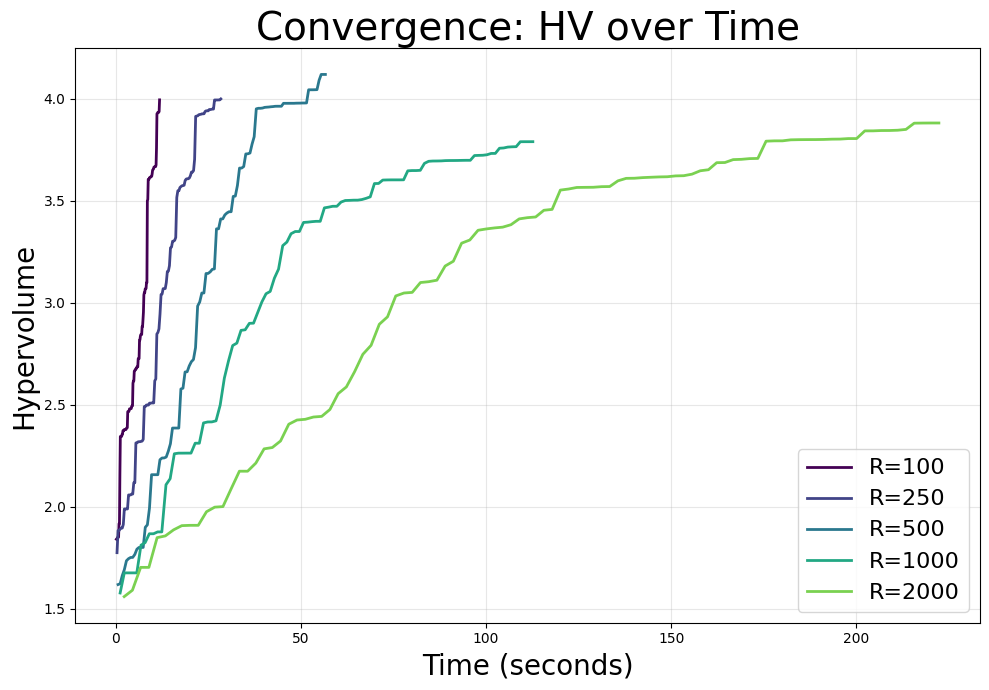

In [29]:
plt.figure(figsize=(10, 7))

colors = plt.colormaps['viridis']
n_R = len(R_test_values) - 1

ax = plt.gca()
for i, R in enumerate(R_test_values[:-1]):  # Exclude R=5000 for clarity
    result = optimization_results[R]['result']
    total_time = optimization_results[R]['runtime']
    
    hv_history = []
    for entry in result.history:
        if entry.opt is not None:
            hv = hv_indicator(entry.opt.get("F"))
            hv_history.append(hv)
    
    # Estimate time per generation (assuming linear)
    n_gens = len(hv_history)
    time_per_gen = total_time / n_gens
    times = [time_per_gen * (g+1) for g in range(n_gens)]
    
    ax.plot(times, hv_history, color=colors(i/n_R), linewidth=2, label=f'R={R}')

ax.set_xlabel('Time (seconds)', fontsize=20)
ax.set_ylabel('Hypervolume', fontsize=20)
ax.set_title('Convergence: HV over Time', fontsize=28)
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/r_impact_over_time.svg', bbox_inches='tight')
plt.show()

## Conclusions: Impact of R on Solution Quality

### Key Findings

1. **Noise Reduction**: Fitness estimate variance decreases as 1/sqrt(R), following the Central Limit Theorem. Doubling R only reduces noise by ~30%.

2. **Solution Quality**: Higher R generally leads to better true solution quality (higher hypervolume, lower IGD after re-evaluation), but with diminishing returns.

3. **Misleading Metrics**: Hypervolume computed during optimization (with noisy fitness) can be misleading. Low-R runs may appear to have good fronts that "collapse" when re-evaluated accurately.

4. **Computational Trade-off**: Runtime scales linearly with R, but quality improvements plateau.

### Recommendations

| Use Case | Recommended R | Rationale |
|----------|---------------|-----------|
| Quick exploration | 100-250 | Fast iteration to understand problem structure |
| Standard optimization | 500-1000 | Good balance of accuracy and speed |
| Final production run | 1000-2000 | More reliable fitness estimates |
| Publication-quality | 2000+ | Minimize noise artifacts |

### Rule of Thumb

For this Top Trumps problem:
- **R=500** provides reasonable accuracy for most purposes
- **R=1000** is recommended for final results
- Going beyond R=2000 has diminishing returns

Consider running optimization with moderate R, then re-evaluating the final Pareto front with high R to validate results.